# r0 — train / val / test visualization

**Run id**: `qwen3-4b-4bit-qlora-s00-r0` &nbsp;·&nbsp; **Corpus**: `spiceland9e-v1.1.0` &nbsp;·&nbsp; **Seed**: `seed_00__351199285`

Visualizes the three SFT splits Diana produced + the eval outputs from Vera's harness. Reads only files already on disk; **no GPU and no model inference required**.

## How to run

From the repo root, on the **host** conda base (no container needed):

```bash
pip install pandas matplotlib numpy   # one-time, if not present
jupyter lab models/runs/qwen3-4b-4bit-qlora-s00-r0/r0_visualization.ipynb
```

Or open the notebook directly in VS Code and hit **Run All**.

## What it covers

1. **Splits + sha pinning** — row counts; file shas vs manifest pins.
2. **Stratification across splits** — Bloom × type × chapter × difficulty distributions; verifies Diana's scenario-grouped Bloom-stratified split held.
3. **Sequence-length distributions** — per-role character counts; p95 outliers.
4. **Training dynamics** — train/eval loss curves, LR schedule, gradient norm (from `checkpoint-*/trainer_state.json`).
5. **Test accuracy slices** — by Bloom × type × chapter; the headline 69.2 % scorable number visualized.
6. **Mechanical checks** — JE-balance / citation / arithmetic-in-prose / standards-smell pass-fail.
7. **Manifest highlights + r1 routing**.

## §0 — Setup

In [1]:
from __future__ import annotations
import json, hashlib
from collections import Counter
from pathlib import Path

# Robust to where the notebook runs from
RUN_DIR = Path('/home/zi/Documents/GitHub/accounting/models/runs/qwen3-4b-4bit-qlora-s00-r0')
if not RUN_DIR.exists():
    RUN_DIR = Path.cwd()
REPO_ROOT = RUN_DIR.parents[2]
SPLIT_DIR = REPO_ROOT / 'eval' / 'sft' / 'splits' / 'seed_00__351199285'

print(f'RUN_DIR    = {RUN_DIR}')
print(f'REPO_ROOT  = {REPO_ROOT}')
print(f'SPLIT_DIR  = {SPLIT_DIR}')

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

try:
    import pandas as pd, numpy as np
    import matplotlib.pyplot as plt
    print(f'pandas {pd.__version__} | numpy {np.__version__} | matplotlib {plt.matplotlib.__version__}')
except ImportError as e:
    print(f'Missing dependency: {e}')
    print('Install with:  pip install pandas matplotlib numpy')
    raise

RUN_DIR    = /home/zi/Documents/GitHub/accounting/models/runs/qwen3-4b-4bit-qlora-s00-r0
REPO_ROOT  = /home/zi/Documents/GitHub/accounting
SPLIT_DIR  = /home/zi/Documents/GitHub/accounting/eval/sft/splits/seed_00__351199285


pandas 2.3.3 | numpy 2.4.1 | matplotlib 3.10.9


## §1 — Splits + sha pinning

In [2]:
train = load_jsonl(SPLIT_DIR / 'train.jsonl')
valid = load_jsonl(SPLIT_DIR / 'valid.jsonl')
test  = load_jsonl(SPLIT_DIR / 'test.jsonl')

manifest    = json.loads((RUN_DIR / 'manifest.json').read_text())
metrics     = json.loads((RUN_DIR / 'test_metrics.json').read_text())
predictions = load_jsonl(RUN_DIR / 'test_predictions.jsonl')
split_man   = json.loads((SPLIT_DIR / 'manifest.json').read_text())

splits = {'train': train, 'valid': valid, 'test': test}

print('Row counts:')
for name, rows in splits.items():
    print(f'  {name:<6}: {len(rows):>5}')

# Sha verification — file sha vs split manifest pin
print('\nFile sha vs split manifest:')
file_shas = split_man.get('file_sha256', {})
for split_name in ['train', 'valid', 'test']:
    file_sha = sha256_of(SPLIT_DIR / f'{split_name}.jsonl')
    pinned   = file_shas.get(split_name) if isinstance(file_shas, dict) else None
    pinned_short = pinned[:16] + '…' if pinned else 'n/a'
    if pinned and file_sha == pinned:
        mark = '✓ match'
    elif pinned:
        mark = '✗ MISMATCH'
    else:
        mark = '(no pin found)'
    print(f'  {split_name:<6} {file_sha[:16]}…  vs  {pinned_short}  {mark}')

print('\nRun anchors (from manifest.json):')
print(f'  run_id              : {manifest["run_id"]}')
print(f'  adapter_sha256      : {manifest["adapter_sha256"][:16]}…')
print(f'  source_jsonl_sha256 : {manifest["source_jsonl_sha256"][:16]}…  ← v1.1.0 corpus anchor')
print(f'  holdout_split_sha256: {manifest["holdout_split_sha256"][:16]}…')
print(f'  base_model          : {manifest["base_model"]}')

Row counts:
  train :  3538
  valid :   450
  test  :   464

File sha vs split manifest:
  train  5dce67f97fe300c1…  vs  5dce67f97fe300c1…  ✓ match
  valid  e01a5ccbd2d3e27f…  vs  e01a5ccbd2d3e27f…  ✓ match
  test   86e2914fb83d221c…  vs  86e2914fb83d221c…  ✓ match

Run anchors (from manifest.json):
  run_id              : qwen3-4b-4bit-qlora-s00-r0
  adapter_sha256      : cd6b7858d7fff033…
  source_jsonl_sha256 : fed6eb17de8be1e4…  ← v1.1.0 corpus anchor
  holdout_split_sha256: 86e2914fb83d221c…
  base_model          : unsloth/Qwen3-4B-Instruct-2507


## §2 — Stratification across splits

Diana's manifest claims scenario-grouped Bloom-stratified 80/10/10. Each panel below shows raw counts per split; if the stratification held, **within-split proportions** (printed under the figure) should be similar across train / valid / test.

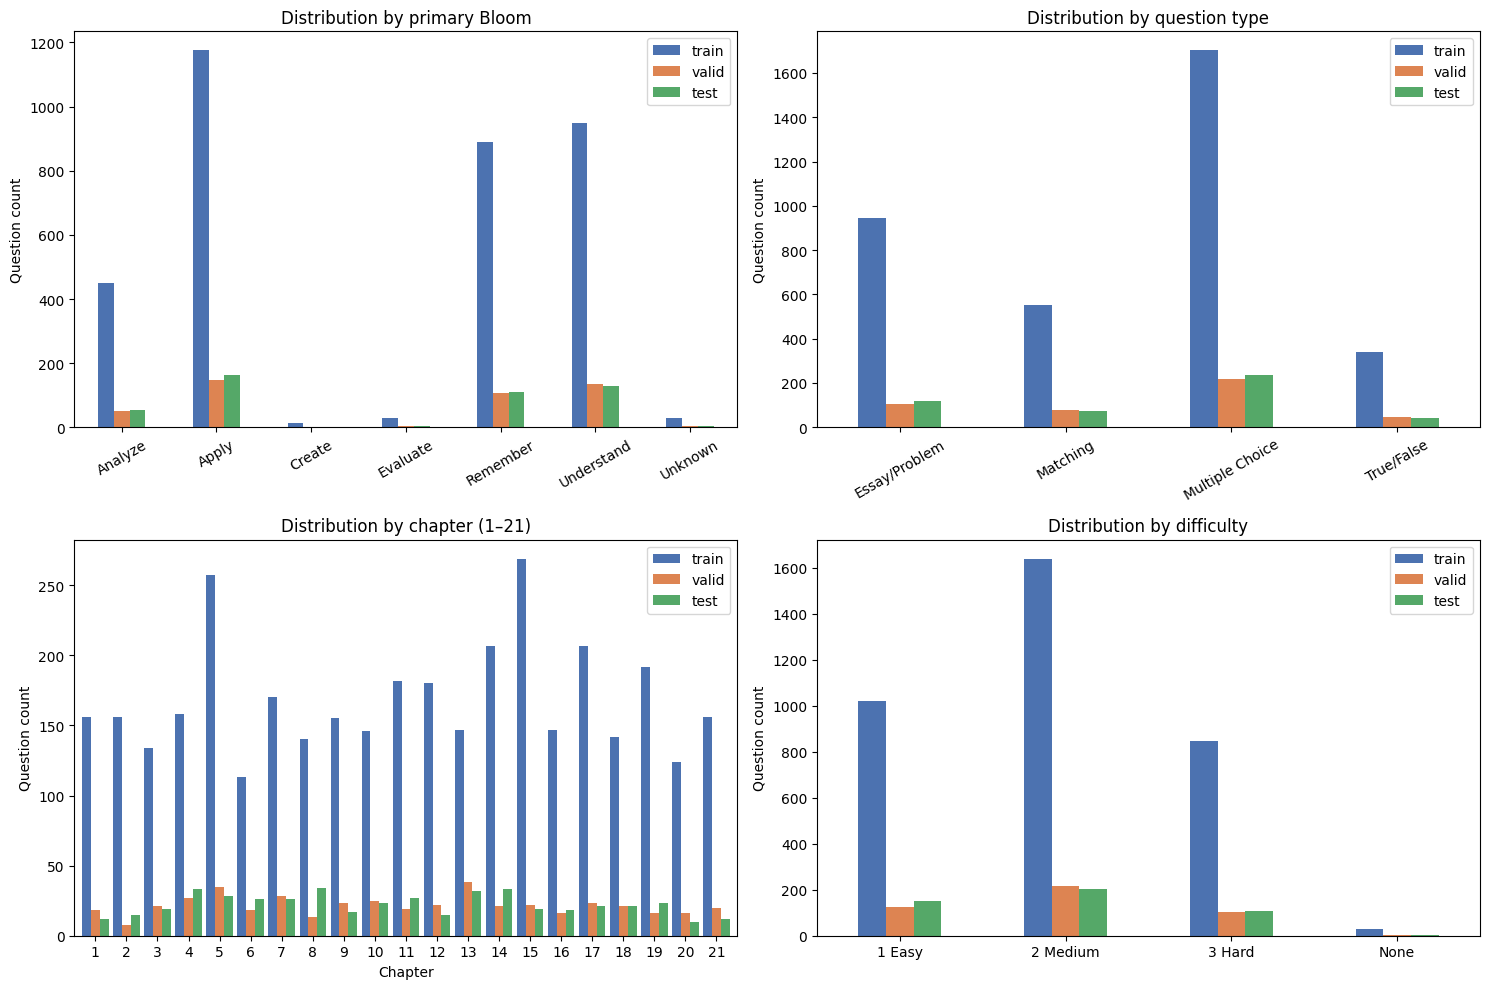

Within-split proportions (%) — should be similar across splits:

By Bloom:
            train  valid  test
Analyze      12.7   11.1  11.4
Apply        33.2   33.1  35.1
Create        0.4    0.4   0.4
Evaluate      0.8    0.7   1.1
Remember     25.2   24.0  23.5
Understand   26.9   29.8  27.8
Unknown       0.8    0.9   0.6

By Type:
                 train  valid  test
Essay/Problem     26.7   23.8  25.2
Matching          15.6   17.8  15.7
Multiple Choice   48.1   48.0  50.4
True/False         9.6   10.4   8.6

By Difficulty:
          train  valid  test
1 Easy     28.9   27.8  32.1
2 Medium   46.3   48.4  44.2
3 Hard     23.9   22.9  23.1
None        0.9    0.9   0.6



In [3]:
def field_counter(rows, field, default='unknown'):
    return Counter(r.get('meta', {}).get(field, default) for r in rows)

def field_dist_df(splits, field, default='unknown', sort_key=None):
    counts = {name: field_counter(rows, field, default) for name, rows in splits.items()}
    keys = sorted(set().union(*[c.keys() for c in counts.values()]),
                  key=sort_key if sort_key else (lambda x: str(x)))
    return pd.DataFrame({n: [c.get(k, 0) for k in keys] for n, c in counts.items()}, index=keys)

colors = ['#4C72B0', '#DD8452', '#55A868']  # train / valid / test

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

bloom_df = field_dist_df(splits, 'primary_bloom')
bloom_df.plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('Distribution by primary Bloom')
axes[0,0].set_ylabel('Question count')
axes[0,0].tick_params(axis='x', rotation=30)

type_df = field_dist_df(splits, 'type')
type_df.plot(kind='bar', ax=axes[0,1], color=colors)
axes[0,1].set_title('Distribution by question type')
axes[0,1].set_ylabel('Question count')
axes[0,1].tick_params(axis='x', rotation=30)

ch_df = field_dist_df(splits, 'chapter', sort_key=lambda x: int(x) if str(x).isdigit() else 999)
ch_df.plot(kind='bar', ax=axes[1,0], color=colors, width=0.85)
axes[1,0].set_title('Distribution by chapter (1–21)')
axes[1,0].set_xlabel('Chapter')
axes[1,0].set_ylabel('Question count')
axes[1,0].tick_params(axis='x', rotation=0)

diff_df = field_dist_df(splits, 'difficulty')
diff_df.plot(kind='bar', ax=axes[1,1], color=colors)
axes[1,1].set_title('Distribution by difficulty')
axes[1,1].set_ylabel('Question count')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Within-split proportions (%) — should be similar across splits:\n')
for field, label in [('primary_bloom', 'Bloom'), ('type', 'Type'), ('difficulty', 'Difficulty')]:
    df = field_dist_df(splits, field)
    pct = (df / df.sum() * 100).round(1)
    print(f'By {label}:')
    print(pct.to_string())
    print()

## §3 — Sequence length distributions

Character counts per chat-template role. Useful for spotting outliers vs Leo's `max_seq_length=2048` budget. The model's tokenizer is `~4 chars / token` for English, so a 2048-token sequence is ~8 000 chars worst-case for input+response combined.

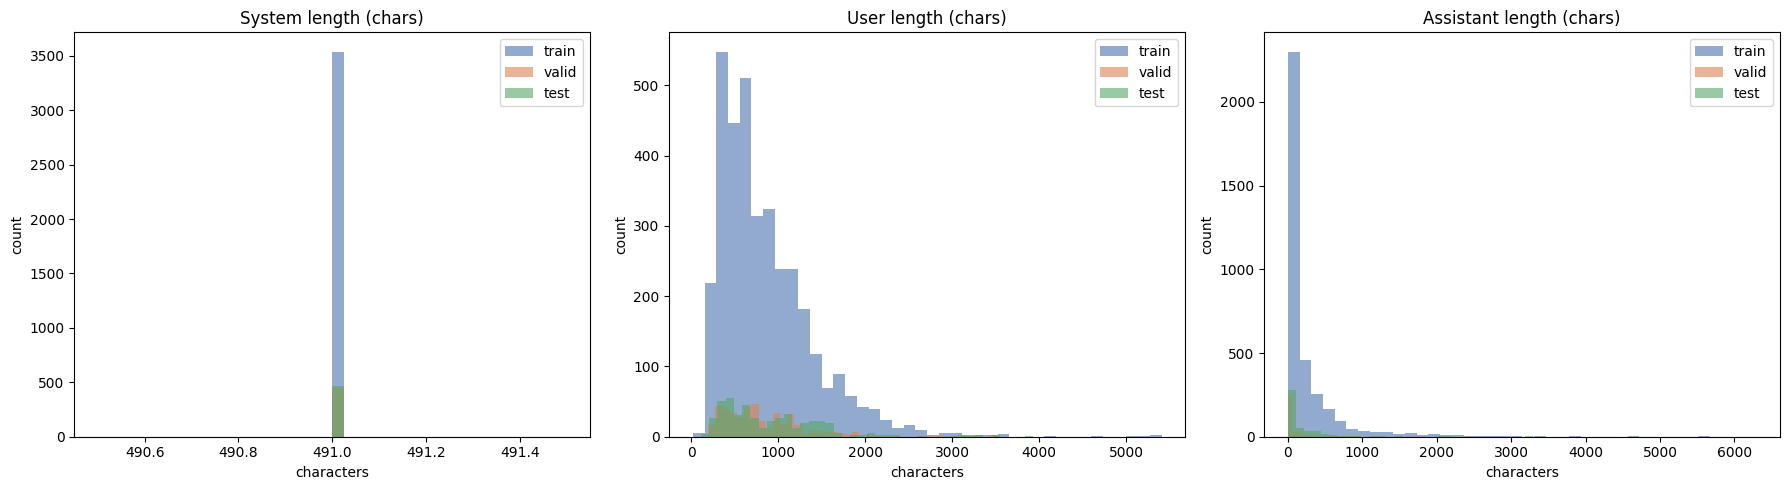

Percentile lengths (chars):
  split  role          p50    p95    max
  train  system        491    491    491
  train  user          712   1904   5406
  train  assistant      29   1151   6297
  valid  system        491    491    491
  valid  user          732   1842   3501
  valid  assistant       9   1144   2444
  test   system        491    491    491
  test   user          767   1997   3931
  test   assistant      35    940   4389


In [4]:
def message_lengths(rows):
    out = {'system': [], 'user': [], 'assistant': []}
    for r in rows:
        for msg in r.get('messages', []):
            role = msg.get('role')
            if role in out:
                out[role].append(len(msg.get('content', '')))
    return out

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, role in zip(axes, ['system', 'user', 'assistant']):
    max_len = 0
    for name, rows in splits.items():
        lengths = message_lengths(rows)[role]
        if lengths:
            ax.hist(lengths, bins=40, alpha=0.6, label=name, color=colors[['train','valid','test'].index(name)])
            max_len = max(max_len, max(lengths))
    ax.set_title(f'{role.title()} length (chars)')
    ax.set_xlabel('characters')
    ax.set_ylabel('count')
    ax.legend()

plt.tight_layout()
plt.show()

print('Percentile lengths (chars):')
print(f'  {"split":<6} {"role":<10} {"p50":>6} {"p95":>6} {"max":>6}')
for name, rows in splits.items():
    lens = message_lengths(rows)
    for role in ['system', 'user', 'assistant']:
        if lens[role]:
            arr = sorted(lens[role])
            p50 = arr[len(arr) // 2]
            p95 = arr[int(len(arr) * 0.95)]
            mx  = arr[-1]
            print(f'  {name:<6} {role:<10} {p50:>6} {p95:>6} {mx:>6}')

## §4 — Training dynamics

From the latest `checkpoint-*/trainer_state.json` — Hugging Face Trainer writes a full `log_history` per checkpoint. Train loss is recorded per `logging_steps`; eval loss per `eval_steps`.

Found 3 checkpoint(s): ['checkpoint-440', 'checkpoint-660', 'checkpoint-770']


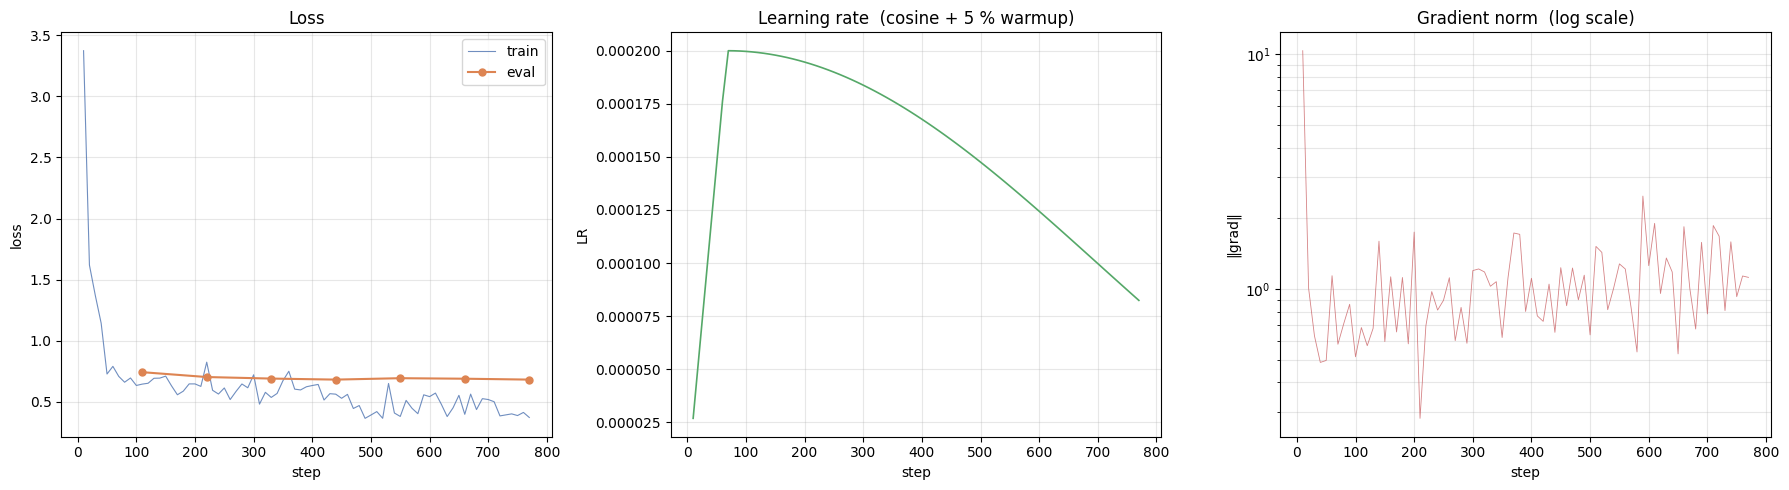


Trainer state summary:
  global_step          : 770  / max_steps 1329
  epoch (reached)      : 1.739  /  num_train_epochs 3
  best_global_step     : 440
  best_metric (eval)   : 0.6823809146881104
  total_flos           : 7.846e+16

Manifest:
  final_train_loss     : 0.6240
  final_dev_loss       : 0.6824
  train/dev gap        : 0.0584
  wall_clock_seconds   : 3436 s  (57.3 min)
  throughput (samples) : 3.09 /s


In [5]:
ckpts = sorted(
    [p for p in RUN_DIR.iterdir() if p.is_dir() and p.name.startswith('checkpoint-')],
    key=lambda p: int(p.name.split('-')[1]),
)
print(f'Found {len(ckpts)} checkpoint(s):', [p.name for p in ckpts])

if not ckpts:
    print('No checkpoint dirs found — skipping training dynamics.')
else:
    state = json.loads((ckpts[-1] / 'trainer_state.json').read_text())
    log   = state.get('log_history', [])

    train_log = [e for e in log if 'loss' in e and 'eval_loss' not in e]
    eval_log  = [e for e in log if 'eval_loss' in e]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    if train_log:
        axes[0].plot([e['step'] for e in train_log],
                     [e['loss']  for e in train_log],
                     label='train', color='#4C72B0', linewidth=0.8, alpha=0.8)
    if eval_log:
        axes[0].plot([e['step']      for e in eval_log],
                     [e['eval_loss'] for e in eval_log],
                     label='eval', color='#DD8452', marker='o', markersize=5, linewidth=1.5)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('step')
    axes[0].set_ylabel('loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # LR schedule
    if train_log and 'learning_rate' in train_log[0]:
        axes[1].plot([e['step']          for e in train_log],
                     [e['learning_rate'] for e in train_log],
                     color='#55A868', linewidth=1.2)
        axes[1].set_title('Learning rate  (cosine + 5 % warmup)')
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('LR')
        axes[1].grid(True, alpha=0.3)

    # Gradient norm — log scale tames the spikes
    if train_log and 'grad_norm' in train_log[0]:
        gn = [(e['step'], e['grad_norm']) for e in train_log if e.get('grad_norm') is not None]
        if gn:
            axes[2].plot([s for s, _ in gn], [g for _, g in gn],
                         color='#C44E52', linewidth=0.6, alpha=0.7)
            axes[2].set_yscale('log')
            axes[2].set_title('Gradient norm  (log scale)')
            axes[2].set_xlabel('step')
            axes[2].set_ylabel('‖grad‖')
            axes[2].grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    # Headline numbers from manifest + trainer state
    print(f'\nTrainer state summary:')
    print(f'  global_step          : {state.get("global_step")}  / max_steps {state.get("max_steps")}')
    print(f'  epoch (reached)      : {state.get("epoch"):.3f}  /  num_train_epochs {state.get("num_train_epochs")}')
    print(f'  best_global_step     : {state.get("best_global_step")}')
    print(f'  best_metric (eval)   : {state.get("best_metric")}')
    print(f'  total_flos           : {state.get("total_flos"):.3e}' if state.get('total_flos') else '')
    print(f'\nManifest:')
    print(f'  final_train_loss     : {manifest["final_train_loss"]:.4f}')
    print(f'  final_dev_loss       : {manifest["final_dev_loss"]:.4f}')
    print(f'  train/dev gap        : {manifest["final_dev_loss"] - manifest["final_train_loss"]:.4f}')
    print(f'  wall_clock_seconds   : {manifest["wall_clock_seconds"]:.0f} s  ({manifest["wall_clock_seconds"]/60:.1f} min)')
    print(f'  throughput (samples) : {manifest["throughput_samples_per_second"]:.2f} /s')

## §5 — Test accuracy slices

From Vera's `test_metrics.json`. Scorable denominator excludes Essay/Problem (`judge_pending` — no LLM-judge wired yet). The red dashed line is the overall scorable accuracy. `n=` labels above each bar are the scorable count.

  (skipped 2 buckets w/ scorable=0: Create jp=2, Unknown jp=3)
  (skipped 1 buckets w/ scorable=0: Essay/Problem jp=117)


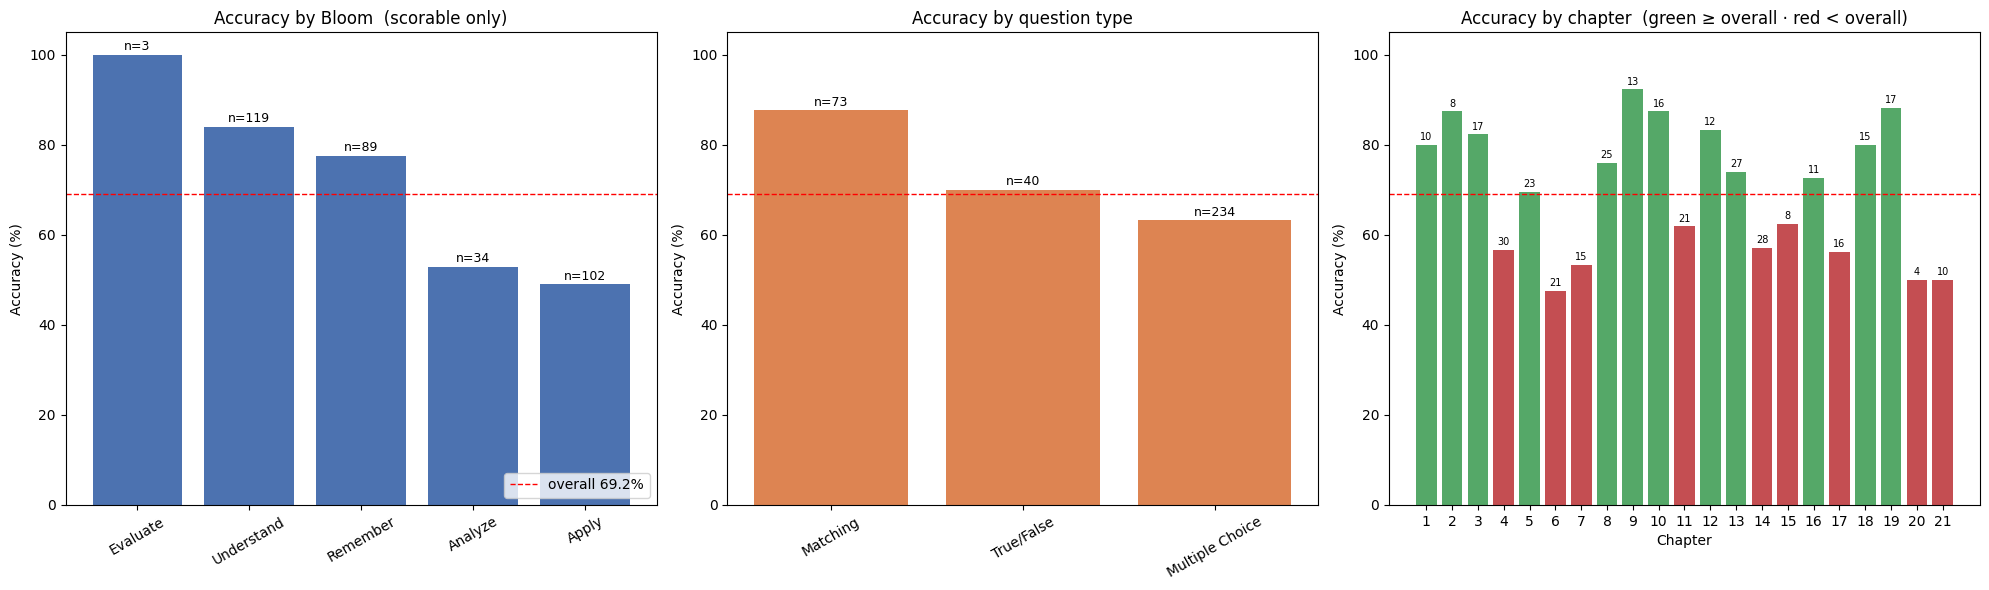

Overall scorable: 69.2 %   (240 / 347)
Judge pending  : 117  (Essay/Problem — no LLM-judge wired)
Total in split : 464


In [6]:
overall = metrics['overall_accuracy_scorable']
overall_pct = overall * 100

def slice_df(d, sort_key=None):
    # Drop entries with accuracy=None (scorable=0, all judge_pending — nothing to plot)
    items = [(k, v['accuracy'], v['scorable'], v.get('judge_pending', 0))
             for k, v in d.items() if v.get('accuracy') is not None]
    if sort_key:
        items.sort(key=sort_key)
    else:
        items.sort(key=lambda t: -t[1])  # by accuracy desc
    skipped = [(k, v) for k, v in d.items() if v.get('accuracy') is None]
    if skipped:
        print('  (skipped {} buckets w/ scorable=0: '.format(len(skipped)) +
              ', '.join('{} jp={}'.format(k, v.get('judge_pending',0)) for k, v in skipped) + ')')
    return pd.DataFrame(items, columns=['bucket', 'accuracy', 'n', 'judge_pending'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Bloom
bloom = slice_df(metrics['by_primary_bloom'])
ax = axes[0]
bars = ax.bar(bloom['bucket'], bloom['accuracy'] * 100, color='#4C72B0')
for b, n in zip(bars, bloom['n']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'n={n}',
            ha='center', fontsize=9)
ax.axhline(overall_pct, color='red', linestyle='--', linewidth=1, label=f'overall {overall_pct:.1f}%')
ax.set_title('Accuracy by Bloom  (scorable only)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=30)

# By type
typ = slice_df(metrics['by_question_type'])
ax = axes[1]
bars = ax.bar(typ['bucket'], typ['accuracy'] * 100, color='#DD8452')
for b, n in zip(bars, typ['n']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'n={n}',
            ha='center', fontsize=9)
ax.axhline(overall_pct, color='red', linestyle='--', linewidth=1)
ax.set_title('Accuracy by question type')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=30)

# By chapter — sort by chapter number for readability
ch = slice_df(metrics['by_chapter'],
              sort_key=lambda t: int(t[0]) if str(t[0]).isdigit() else 999)
ax = axes[2]
# color bars by accuracy: red if below overall, green if at-or-above
bar_colors = ['#55A868' if a >= overall else '#C44E52' for a in ch['accuracy']]
bars = ax.bar(ch['bucket'].astype(str), ch['accuracy'] * 100, color=bar_colors)
for b, n in zip(bars, ch['n']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{n}',
            ha='center', fontsize=7)
ax.axhline(overall_pct, color='red', linestyle='--', linewidth=1)
ax.set_title('Accuracy by chapter  (green ≥ overall · red < overall)')
ax.set_xlabel('Chapter')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

n_correct = sum(v.get('correct', 0) for v in metrics['by_primary_bloom'].values())
print(f'Overall scorable: {overall_pct:.1f} %   ({n_correct} / {metrics["n_scorable"]})')
print(f'Judge pending  : {metrics["n_judge_pending"]}  (Essay/Problem — no LLM-judge wired)')
print(f'Total in split : {metrics["n_questions"]}')

## §6 — Mechanical checks

Vera's deterministic post-hoc checks. Gate = PASS only if violation counts are at zero. At r0 the citation + arithmetic gates fail by design (no RAG, no tool curriculum) — they're r1 scope, not r0 quality.

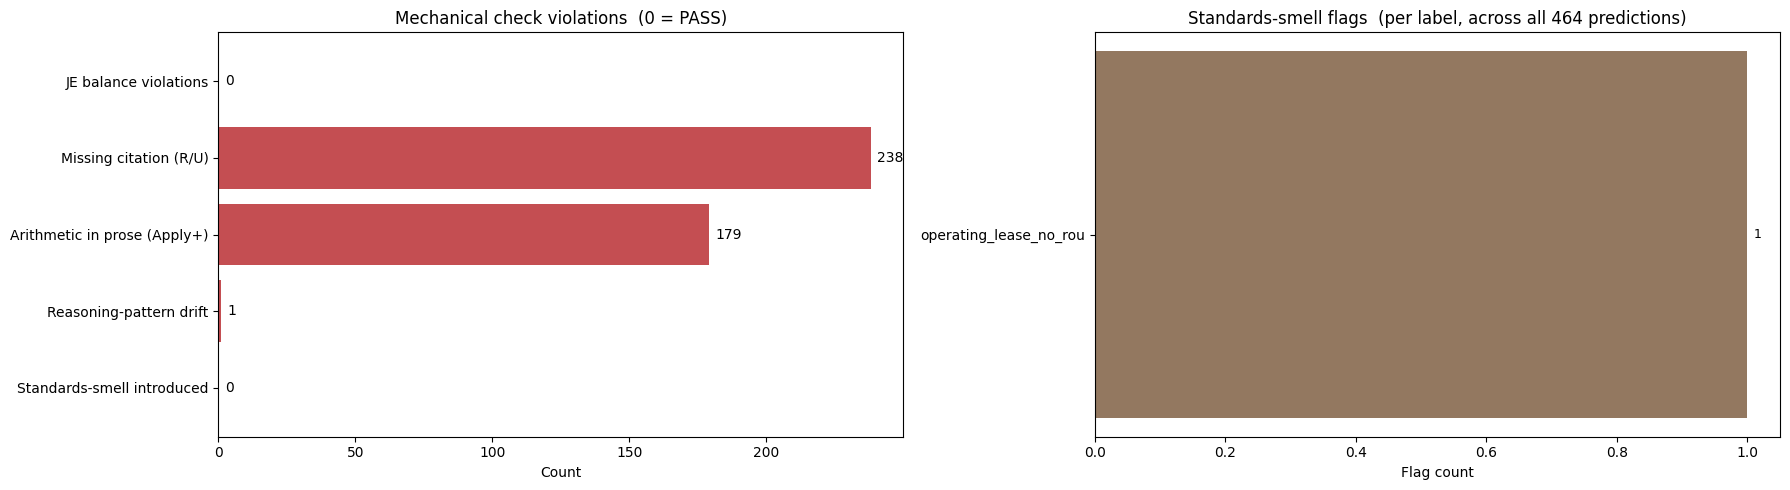

Mechanical gate pass : False
Smell gate pass      : True
Total smell flags    : 1
Smells introduced by model (not in gold): 0


In [7]:
mc = metrics['mechanical_checks']

rows = [
    ('JE balance violations',           mc.get('je_balance_violations', 0)),
    ('Missing citation (R/U)',           mc.get('missing_citation_violations', 0)),
    ('Arithmetic in prose (Apply+)',     mc.get('arith_in_prose_violations', 0)),
    ('Reasoning-pattern drift',          mc.get('reasoning_pattern_drift', 0)),
    ('Standards-smell introduced',       mc.get('smell_introduced_by_model', 0)),
]
labels  = [r[0] for r in rows]
counts  = [r[1] for r in rows]
is_zero = [c == 0 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
bar_colors = ['#55A868' if z else '#C44E52' for z in is_zero]
bars = ax.barh(labels, counts, color=bar_colors)
for b, c in zip(bars, counts):
    ax.text(b.get_width() + max(counts)*0.01, b.get_y() + b.get_height()/2,
            str(c), va='center', fontsize=10)
ax.set_title('Mechanical check violations  (0 = PASS)')
ax.set_xlabel('Count')
ax.invert_yaxis()

# Standards-smell breakdown by label
smell_by = mc.get('smell_by_label', {})
if smell_by:
    ax = axes[1]
    smell_items = sorted(smell_by.items(), key=lambda kv: -kv[1])
    sm_labels = [k for k, _ in smell_items]
    sm_counts = [v for _, v in smell_items]
    ax.barh(sm_labels, sm_counts, color='#937860')
    for i, c in enumerate(sm_counts):
        ax.text(c + max(sm_counts)*0.01, i, str(c), va='center', fontsize=9)
    ax.set_title('Standards-smell flags  (per label, across all 464 predictions)')
    ax.set_xlabel('Flag count')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Mechanical gate pass : {mc.get("gate_pass", "unknown")}')
print(f'Smell gate pass      : {mc.get("smell_gate_pass", "unknown")}')
print(f'Total smell flags    : {mc.get("smell_flags_total", 0)}')
print(f'Smells introduced by model (not in gold): {mc.get("smell_introduced_by_model", 0)}')

## §7 — Manifest highlights + r1 routing

Headline numbers and the routing for the next training iteration.

In [8]:
def line(k, v):
    print(f'  {k:<28} : {v}')

print('Manifest reproducibility record:')
line('run_id',            manifest['run_id'])
line('base_model',        manifest['base_model'])
line('tokenizer_revision',manifest.get('tokenizer_revision', '(n/a)'))
line('adapter_sha256',    manifest['adapter_sha256'][:16] + '…')
line('corpus_anchor',     manifest.get('corpus_anchor', '(n/a)'))
line('source_jsonl_sha',  manifest['source_jsonl_sha256'][:16] + '…')
line('seed_int',          manifest['seed_int'])
line('container_image',   manifest.get('container_image', '(n/a)'))
line('unsloth_version',   manifest.get('unsloth_version', '(n/a)'))
line('cuda_compute_cap',  manifest.get('cuda_compute_cap', '(n/a)'))
line('gpu_device',        manifest.get('gpu_device', '(n/a)'))

print('\nRecipe:')
for k, v in manifest.get('recipe', {}).items():
    if isinstance(v, list):
        v = ', '.join(v)
    if isinstance(v, str) and len(v) > 120:
        v = v[:117] + '…'
    line(k, v)

print('\nHeadline:')
line('overall_accuracy_scorable', f'{metrics["overall_accuracy_scorable"]*100:.1f} %  ({sum(v["correct"] for v in metrics["by_primary_bloom"].values())} / {metrics["n_scorable"]})')
line('n_judge_pending',            metrics['n_judge_pending'])
line('final_train_loss',           f'{manifest["final_train_loss"]:.4f}')
line('final_dev_loss',             f'{manifest["final_dev_loss"]:.4f}')
line('wall_clock',                 f'{manifest["wall_clock_seconds"]/60:.1f} min')

print('\nr1 routing (per Vera + Pat earlier in this session):')
print('  • Citation gate (238 missing at R/U)   → Riley (RAG + citation emission)')
print('  • Arithmetic-in-prose (179 violations) → Solomon (deterministic tool curriculum)')
print('  • Ch 6 TVM 47.6 %                      → Solomon (TVM tool — PV/FV/EIR/annuity)')
print('  • Supersession bake (deferred Path B)  → Diana (v1.1.1 split-record meta plumbing)')
print('  • Loss weighting 0.85/0.15             → Leo + Pat (custom collator after v1.1.1)')

Manifest reproducibility record:
  run_id                       : qwen3-4b-4bit-qlora-s00-r0
  base_model                   : unsloth/Qwen3-4B-Instruct-2507
  tokenizer_revision           : unsloth/qwen3-4b-instruct-2507-unsloth-bnb-4bit
  adapter_sha256               : cd6b7858d7fff033…
  corpus_anchor                : spiceland9e-v1.1.0
  source_jsonl_sha             : fed6eb17de8be1e4…
  seed_int                     : 351199285
  container_image              : nvcr.io/nvidia/pytorch:25.11-py3
  unsloth_version              : 2026.5.5
  cuda_compute_cap             : 12.1
  gpu_device                   : NVIDIA GB10

Recipe:
  method                       : qlora-4bit
  rank                         : 16
  alpha                        : 32
  dropout                      : 0
  target_modules               : q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
  max_seq_length               : 2048
  per_device_train_batch_size  : 2
  gradient_accumulation_steps  : 4
  learning_